## Data Analysis

In [179]:
# import the necessary libraries
import time
import rasterio
import osmnx as ox
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import geopandas as gpd
from pysheds.grid import Grid
import matplotlib.pyplot as plt
from shapely.geometry import Point
from rasterstats import zonal_stats
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [180]:
# read the dataset
df = pd.read_csv("Roads.csv")
df1 = pd.read_csv("Nigeria_LGAs.csv")

In [181]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1787576 entries, 0 to 1787575
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   osm_id        int64  
 1   code          int64  
 2   fclass        object 
 3   name          object 
 4   ref           object 
 5   oneway        object 
 6   maxspeed      int64  
 7   layer         int64  
 8   bridge        object 
 9   tunnel        object 
 10  Length        float64
 11  AREA_SqKM     float64
 12  Road_density  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 177.3+ MB


In [182]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OBJECTID_1  774 non-null    int64  
 1   OBJECTID    774 non-null    int64  
 2   STATENAME   774 non-null    object 
 3   NAME_1      774 non-null    object 
 4   Geo_Politi  774 non-null    object 
 5   Population  774 non-null    float64
 6   Headquarte  774 non-null    object 
 7   MALE_POP    774 non-null    float64
 8   FEML_POP    774 non-null    float64
 9   Source      774 non-null    object 
 10  AREA_SqKM   774 non-null    float64
 11  2006        774 non-null    int64  
 12  1991        774 non-null    int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 78.7+ KB


In [183]:
# merging two datasets 
df = pd.merge(df, df1, on='AREA_SqKM', how='inner')
df

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,2006,1991
0,178678000,5114,secondary,NaN,NaN,B,0,1,T,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
1,178678001,5114,secondary,NaN,NaN,B,0,1,T,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
2,178678002,5114,secondary,NaN,NaN,B,0,0,F,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
3,178678004,5114,secondary,NaN,NaN,B,0,0,F,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
4,178770907,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Kaduna,Lere,North_Central_Geo-political_Zone,331161.0,Saminaka,172005.0,159155.0,National Population Commission,339740,331161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780520,1467601535,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633
1780521,1469762952,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633
1780522,1473906711,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633
1780523,1473906712,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Zamfara,Bukkuyum,North_West_Geo-political_Zone,211633.0,Bukkuyum,104977.0,106655.0,National Population Commission,216348,211633


In [184]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780525 entries, 0 to 1780524
Data columns (total 25 columns):
 #   Column        Dtype  
---  ------        -----  
 0   osm_id        int64  
 1   code          int64  
 2   fclass        object 
 3   name          object 
 4   ref           object 
 5   oneway        object 
 6   maxspeed      int64  
 7   layer         int64  
 8   bridge        object 
 9   tunnel        object 
 10  Length        float64
 11  AREA_SqKM     float64
 12  Road_density  float64
 13  OBJECTID_1    int64  
 14  OBJECTID      int64  
 15  STATENAME     object 
 16  NAME_1        object 
 17  Geo_Politi    object 
 18  Population    float64
 19  Headquarte    object 
 20  MALE_POP      float64
 21  FEML_POP      float64
 22  Source        object 
 23  2006          int64  
 24  1991          int64  
dtypes: float64(6), int64(8), object(11)
memory usage: 339.6+ MB


In [185]:
# print column names
print(df1.head())
print(df1.columns)

print(df.head())
print(df.columns)

   OBJECTID_1  OBJECTID STATENAME        NAME_1  \
0           1         1    Kaduna          Lere   
1           2         2    Kaduna         Zaria   
2           3         3    Kaduna  Zangon-Kataf   
3           4         4    Kaduna  Birnin-Gwari   
4           5         5    Kaduna         Sanga   

                         Geo_Politi  Population    Headquarte  MALE_POP  \
0  North_Central_Geo-political_Zone    331161.0      Saminaka  172005.0   
1  North_Central_Geo-political_Zone    408198.0         Zaria  216075.0   
2  North_Central_Geo-political_Zone    316370.0        Zonkwa  160630.0   
3  North_Central_Geo-political_Zone    252363.0  Birnin Gwari  130432.0   
4  North_Central_Geo-political_Zone    149333.0        Gwantu   75178.0   

   FEML_POP                          Source    AREA_SqKM    2006    1991  
0  159155.0  National Population Commission  2157.089074  339740  331161  
1  192122.0  National Population Commission   299.811471  406990  408198  
2  155739.0  Nati

In [186]:
# working only on data pertaining to Rivers state
df = df.loc[df['STATENAME'] == 'Rivers']
df

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,...,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,2006,1991
1585149,354327683,5113,primary,Glory Land Drive Roundabout to East West Road,F103,F,100,0,F,F,...,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,166324,166747
1585150,355470677,5121,unclassified,NaN,NaN,B,0,0,F,F,...,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,166324,166747
1585151,373584073,5115,tertiary,NaN,NaN,B,0,0,F,F,...,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,166324,166747
1585152,373584742,5115,tertiary,NaN,NaN,B,0,0,F,F,...,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,166324,166747
1585153,374422932,5121,unclassified,NaN,NaN,B,50,0,F,F,...,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,166324,166747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1630836,1233882835,5154,path,NaN,NaN,B,0,0,F,F,...,Rivers,Emuoha,South_South_Geo-political_Zone,201901.0,Emuoha,103942.0,97958.0,National Population Commission,201057,201901
1630837,1233882927,5154,path,NaN,NaN,B,0,0,F,F,...,Rivers,Emuoha,South_South_Geo-political_Zone,201901.0,Emuoha,103942.0,97958.0,National Population Commission,201057,201901
1630838,1233882928,5154,path,NaN,NaN,B,0,0,F,F,...,Rivers,Emuoha,South_South_Geo-political_Zone,201901.0,Emuoha,103942.0,97958.0,National Population Commission,201057,201901
1630839,1233882929,5154,path,NaN,NaN,B,0,0,F,F,...,Rivers,Emuoha,South_South_Geo-political_Zone,201901.0,Emuoha,103942.0,97958.0,National Population Commission,201057,201901


In [187]:
# Load your data
df = pd.read_csv("Nigeria_LGAs.csv")

# Filter Rivers State
rivers_lgas = df[df["STATENAME"] == "Rivers"]["NAME_1"].unique().tolist()

# Set up geocoder
geolocator = Nominatim(user_agent="flood_prediction_rivers")

# Get coordinates for each LGA
coordinates = {}
for i, lga in enumerate(rivers_lgas, 1):
    try:
        print(f"Processing {i}/{len(rivers_lgas)}: {lga}")
        
        # Search for LGA
        location = geolocator.geocode(f"{lga}, Rivers State, Nigeria")
        
        if location:
            coordinates[lga] = {
                "latitude": location.latitude,
                "longitude": location.longitude
            }
            print(f"  ✓ Success: {location.latitude:.4f}, {location.longitude:.4f}")
        else:
            # Try without state
            location = geolocator.geocode(f"{lga}, Nigeria")
            if location:
                coordinates[lga] = {
                    "latitude": location.latitude,
                    "longitude": location.longitude
                }
                print(f"  ✓ Found (fallback): {location.latitude:.4f}, {location.longitude:.4f}")
            else:
                print(f"  ✗ Not found")
        
        # Be respectful to the API - wait 1 second between requests
        time.sleep(1)
        
    except Exception as e:
        print(f"  ✗ Error: {e}")

# Convert to DataFrame
coords_df = pd.DataFrame.from_dict(coordinates, orient='index')
coords_df.reset_index(inplace=True)
coords_df.columns = ["LGA", "latitude", "longitude"]

# Save to CSV for future use
coords_df.to_csv("rivers_lgas_coordinates.csv", index=False)

print("\n" + "="*50)
print(f"Successfully geocoded {len(coords_df)} out of {len(rivers_lgas)} LGAs")
print("\nFirst 5 results:")
print(coords_df.head())

# Display summary statistics
print("\nCoordinate ranges:")
print(f"Latitude: {coords_df['latitude'].min():.4f} to {coords_df['latitude'].max():.4f}")
print(f"Longitude: {coords_df['longitude'].min():.4f} to {coords_df['longitude'].max():.4f}")


Processing 1/23: Ahoada East
  ✓ Success: 5.0505, 6.6430
Processing 2/23: Ogba/Egbema/Ndoni
  ✓ Success: 5.4513, 6.6409
Processing 3/23: Andoni
  ✓ Success: 4.5061, 7.4073
Processing 4/23: Degema
  ✓ Success: 4.5906, 6.9389
Processing 5/23: Ogu/Bolo
  ✓ Success: 4.6742, 7.2017
Processing 6/23: Ahoada West
  ✓ Success: 5.0420, 6.5131
Processing 7/23: Oyigbo
  ✓ Success: 4.8814, 7.1334
Processing 8/23: Omumma
  ✓ Success: 5.0931, 7.2354
Processing 9/23: Akuku Toru
  ✓ Success: 4.5336, 6.6787
Processing 10/23: Bonny
  ✓ Success: 4.5058, 7.2035
Processing 11/23: Abua/Odual
  ✓ Success: 4.8469, 6.5600
Processing 12/23: Etche
  ✓ Success: 5.0765, 7.0926
Processing 13/23: Port-Harcourt
  ✓ Success: 4.7677, 7.0189
Processing 14/23: Obio/Akpor
  ✓ Success: 4.8663, 7.0202
Processing 15/23: Ikwerre
  ✓ Success: 5.0705, 6.8820
Processing 16/23: Gokana
  ✓ Success: 4.6579, 7.2945
Processing 17/23: Tai
  ✓ Success: 4.7698, 7.2620
Processing 18/23: Khana
  ✓ Success: 4.6694, 7.4375
Processing 19/23: 

In [188]:
# read data
df2 = pd.read_csv("rivers_lgas_coordinates.csv")
df2

,LGA,latitude,longitude
0,Ahoada East,5.050498,6.642960
1,Ogba/Egbema/Ndoni,5.451286,6.640918
2,Andoni,4.506146,7.407307
3,Degema,4.590561,6.938948
4,Ogu/Bolo,4.674218,7.201702
5,Ahoada West,5.041966,6.513134
6,Oyigbo,4.881408,7.133447
7,Omumma,5.093120,7.235432
8,Akuku Toru,4.533629,6.678671
9,Bonny,4.505781,7.203466


In [189]:
# merging two dataset
df = pd.merge(df, df2, left_on='NAME_1', right_on='LGA')
df

,OBJECTID_1,OBJECTID,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,AREA_SqKM,2006,1991,LGA,latitude,longitude
0,683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,341.152699,166324,166747,Ahoada East,5.050498,6.642960
1,684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,147188.0,136821.0,National Population Commission,969.685418,283294,284010,Ogba/Egbema/Ndoni,5.451286,6.640918
2,685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,110284.0,100724.0,National Population Commission,232.837758,217924,211009,Andoni,4.506146,7.407307
3,686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,129982.0,119790.0,National Population Commission,1010.833213,249467,249773,Degema,4.590561,6.938948
4,687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,38576.0,36106.0,National Population Commission,88.698300,75282,74683,Ogu/Bolo,4.674218,7.201702
5,688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,129278.0,120146.0,National Population Commission,403.430852,249232,249425,Ahoada West,5.041966,6.513134
6,689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,65441.0,57245.0,National Population Commission,247.776242,125331,122687,Oyigbo,4.881408,7.133447
7,690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,50947.0,49418.0,National Population Commission,169.994120,100388,100366,Omumma,5.093120,7.235432
8,691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,81705.0,74300.0,National Population Commission,1443.731481,161103,156006,Akuku Toru,4.533629,6.678671
9,692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,113458.0,101899.0,National Population Commission,641.712073,214983,215358,Bonny,4.505781,7.203466


In [190]:
# opening a raster file
df3 = rasterio.open("chirps-v2.0.2026.04.tif")

print(df3.count)      # number of bands
print(df3.crs)
print(df3.bounds)

1
EPSG:4326
BoundingBox(left=-20.0, bottom=-40.000001192092896, right=55.00000111758709, top=40.0)


In [191]:
# read shape file
lgas = gpd.read_file("Rivers LGA.shp")
rivers_boundary = lgas.dissolve()

In [192]:
# extracting rainfall data from raster file
stats = zonal_stats(
    lgas,
    "chirps-v2.0.2026.04.tif",
    stats=["mean", "sum", "max", "min"],
    geojson_out=True
)

In [193]:
# getting rainfall data for each LGA
rainfall_lga = gpd.GeoDataFrame.from_features(stats)
rainfall_lga.head()

,geometry,OBJECTID_1,OBJECTID,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,AREA_SqKM,2006,1991,min,max,mean,sum
0,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,341.152699,166324,166747,173.753983,188.891495,184.417203,2028.589233
1,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,147188.0,136821.0,National Population Commission,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258
2,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,110284.0,100724.0,National Population Commission,232.837758,217924,211009,189.803009,206.841003,197.474731,1184.848389
3,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,129982.0,119790.0,National Population Commission,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164
4,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,38576.0,36106.0,National Population Commission,88.698300,75282,74683,198.552078,215.176224,204.848002,614.544006


In [194]:
rainfall_lga.to_file("rivers_lga_rainfall.shp")

C:\Users\unity\anaconda3\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [195]:
df.columns

Index(['OBJECTID_1', 'OBJECTID', 'STATENAME', 'NAME_1', 'Geo_Politi',
       'Population', 'Headquarte', 'MALE_POP', 'FEML_POP', 'Source',
       'AREA_SqKM', '2006', '1991', 'LGA', 'latitude', 'longitude'],
      dtype='object')

In [196]:
# drop columns
df = df.drop(columns = ['OBJECTID_1', 'Source', 'OBJECTID', 'STATENAME', 'Geo_Politi', 'Population', 'Headquarte', 'MALE_POP', 'FEML_POP', 'AREA_SqKM', '2006', '1991', 'NAME_1'], axis = 1)
df

,LGA,latitude,longitude
0,Ahoada East,5.050498,6.642960
1,Ogba/Egbema/Ndoni,5.451286,6.640918
2,Andoni,4.506146,7.407307
3,Degema,4.590561,6.938948
4,Ogu/Bolo,4.674218,7.201702
5,Ahoada West,5.041966,6.513134
6,Oyigbo,4.881408,7.133447
7,Omumma,5.093120,7.235432
8,Akuku Toru,4.533629,6.678671
9,Bonny,4.505781,7.203466


In [197]:
# merge data
df = pd.merge(df, rainfall_lga, right_on ='NAME_1', left_on = 'LGA')
df

,LGA,latitude,longitude,geometry,OBJECTID_1,OBJECTID,STATENAME,NAME_1,Geo_Politi,Population,...,MALE_POP,FEML_POP,Source,AREA_SqKM,2006,1991,min,max,mean,sum
0,Ahoada East,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,...,87419.0,79327.0,National Population Commission,341.152699,166324,166747,173.753983,188.891495,184.417203,2028.589233
1,Ogba/Egbema/Ndoni,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,...,147188.0,136821.0,National Population Commission,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258
2,Andoni,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,...,110284.0,100724.0,National Population Commission,232.837758,217924,211009,189.803009,206.841003,197.474731,1184.848389
3,Degema,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,...,129982.0,119790.0,National Population Commission,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164
4,Ogu/Bolo,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,...,38576.0,36106.0,National Population Commission,88.698300,75282,74683,198.552078,215.176224,204.848002,614.544006
5,Ahoada West,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,...,129278.0,120146.0,National Population Commission,403.430852,249232,249425,177.713074,189.042526,182.719831,2558.077637
6,Oyigbo,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,...,65441.0,57245.0,National Population Commission,247.776242,125331,122687,190.540726,215.305298,204.320469,1430.243286
7,Omumma,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,...,50947.0,49418.0,National Population Commission,169.994120,100388,100366,177.757629,208.786011,197.945557,1187.673340
8,Akuku Toru,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,...,81705.0,74300.0,National Population Commission,1443.731481,161103,156006,179.636902,216.551071,194.349355,8940.070312
9,Bonny,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,...,113458.0,101899.0,National Population Commission,641.712073,214983,215358,203.621292,250.252518,223.039906,4906.877930


In [198]:
# drop column 
df = df.drop('LGA', axis = 1)
df

,latitude,longitude,geometry,OBJECTID_1,OBJECTID,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,AREA_SqKM,2006,1991,min,max,mean,sum
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,341.152699,166324,166747,173.753983,188.891495,184.417203,2028.589233
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,147188.0,136821.0,National Population Commission,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,110284.0,100724.0,National Population Commission,232.837758,217924,211009,189.803009,206.841003,197.474731,1184.848389
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,129982.0,119790.0,National Population Commission,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,38576.0,36106.0,National Population Commission,88.698300,75282,74683,198.552078,215.176224,204.848002,614.544006
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,129278.0,120146.0,National Population Commission,403.430852,249232,249425,177.713074,189.042526,182.719831,2558.077637
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,65441.0,57245.0,National Population Commission,247.776242,125331,122687,190.540726,215.305298,204.320469,1430.243286
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,50947.0,49418.0,National Population Commission,169.994120,100388,100366,177.757629,208.786011,197.945557,1187.673340
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,81705.0,74300.0,National Population Commission,1443.731481,161103,156006,179.636902,216.551071,194.349355,8940.070312
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,113458.0,101899.0,National Population Commission,641.712073,214983,215358,203.621292,250.252518,223.039906,4906.877930


In [199]:
print(df.columns)

Index(['latitude', 'longitude', 'geometry', 'OBJECTID_1', 'OBJECTID',
       'STATENAME', 'NAME_1', 'Geo_Politi', 'Population', 'Headquarte',
       'MALE_POP', 'FEML_POP', 'Source', 'AREA_SqKM', '2006', '1991', 'min',
       'max', 'mean', 'sum'],
      dtype='object')


In [200]:
# read CSV files
df4 = pd.read_csv("Slope_mean.csv")
df5 = pd.read_csv("DEM_mean.csv")

In [201]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OBJECTID_1  23 non-null     int64  
 1   OBJECTID    23 non-null     int64  
 2   STATENAME   23 non-null     object 
 3   NAME_1      23 non-null     object 
 4   Geo_Politi  23 non-null     object 
 5   Population  23 non-null     float64
 6   Headquarte  23 non-null     object 
 7   MALE_POP    23 non-null     float64
 8   FEML_POP    23 non-null     float64
 9   Source      23 non-null     object 
 10  AREA_SqKM   23 non-null     float64
 11  2006        23 non-null     int64  
 12  1991        23 non-null     int64  
 13  _slope_mea  11 non-null     float64
dtypes: float64(5), int64(4), object(5)
memory usage: 2.6+ KB


In [202]:
# drop columns
df4 = df4.drop(["OBJECTID_1", "OBJECTID", "STATENAME", "Geo_Politi", "Population", "Headquarte", "MALE_POP", "FEML_POP", "Source", "AREA_SqKM", "2006", "1991"], axis = 1)
df4

,NAME_1,_slope_mea
0,Ahoada East,89.519019
1,Ogba/Egbema/Ndoni,NaN
2,Andoni,NaN
3,Degema,75.711960
4,Ogu/Bolo,NaN
5,Ahoada West,89.068555
6,Oyigbo,NaN
7,Omumma,NaN
8,Akuku Toru,79.110913
9,Bonny,NaN


In [203]:
# drop columns
df5 = df5.drop(["OBJECTID_1", "OBJECTID", "STATENAME", "Geo_Politi", "Population", "Headquarte", "MALE_POP", "FEML_POP", "Source", "AREA_SqKM", "2006", "1991"], axis = 1)
df5

,NAME_1,_dem_mean
0,Ahoada East,13.304846
1,Ogba/Egbema/Ndoni,NaN
2,Andoni,NaN
3,Degema,6.732322
4,Ogu/Bolo,NaN
5,Ahoada West,18.863808
6,Oyigbo,NaN
7,Omumma,NaN
8,Akuku Toru,8.025339
9,Bonny,NaN


In [204]:
# merge data
df1 = pd.merge(df4, df5, on = 'NAME_1', how = 'inner')
df1

,NAME_1,_slope_mea,_dem_mean
0,Ahoada East,89.519019,13.304846
1,Ogba/Egbema/Ndoni,NaN,NaN
2,Andoni,NaN,NaN
3,Degema,75.711960,6.732322
4,Ogu/Bolo,NaN,NaN
5,Ahoada West,89.068555,18.863808
6,Oyigbo,NaN,NaN
7,Omumma,NaN,NaN
8,Akuku Toru,79.110913,8.025339
9,Bonny,NaN,NaN


In [205]:
# fill "Nan" values with zero
df1 = df1.fillna(0)
df1

,NAME_1,_slope_mea,_dem_mean
0,Ahoada East,89.519019,13.304846
1,Ogba/Egbema/Ndoni,0.000000,0.000000
2,Andoni,0.000000,0.000000
3,Degema,75.711960,6.732322
4,Ogu/Bolo,0.000000,0.000000
5,Ahoada West,89.068555,18.863808
6,Oyigbo,0.000000,0.000000
7,Omumma,0.000000,0.000000
8,Akuku Toru,79.110913,8.025339
9,Bonny,0.000000,0.000000


In [206]:
# round values to two decimal places
df1['_slope_mea'] = df1['_slope_mea'].round(2)
df1['_dem_mean'] = df1['_dem_mean'].round(2)
df1

,NAME_1,_slope_mea,_dem_mean
0,Ahoada East,89.52,13.30
1,Ogba/Egbema/Ndoni,0.00,0.00
2,Andoni,0.00,0.00
3,Degema,75.71,6.73
4,Ogu/Bolo,0.00,0.00
5,Ahoada West,89.07,18.86
6,Oyigbo,0.00,0.00
7,Omumma,0.00,0.00
8,Akuku Toru,79.11,8.03
9,Bonny,0.00,0.00


In [207]:
# merge datasets
df = pd.merge(df, df1, on = 'NAME_1', how = 'inner')
df

,latitude,longitude,geometry,OBJECTID_1,OBJECTID,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,...,Source,AREA_SqKM,2006,1991,min,max,mean,sum,_slope_mea,_dem_mean
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,National Population Commission,341.152699,166324,166747,173.753983,188.891495,184.417203,2028.589233,89.52,13.30
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,National Population Commission,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258,0.00,0.00
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,National Population Commission,232.837758,217924,211009,189.803009,206.841003,197.474731,1184.848389,0.00,0.00
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,National Population Commission,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164,75.71,6.73
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,National Population Commission,88.698300,75282,74683,198.552078,215.176224,204.848002,614.544006,0.00,0.00
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,National Population Commission,403.430852,249232,249425,177.713074,189.042526,182.719831,2558.077637,89.07,18.86
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,National Population Commission,247.776242,125331,122687,190.540726,215.305298,204.320469,1430.243286,0.00,0.00
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,National Population Commission,169.994120,100388,100366,177.757629,208.786011,197.945557,1187.673340,0.00,0.00
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,National Population Commission,1443.731481,161103,156006,179.636902,216.551071,194.349355,8940.070312,79.11,8.03
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,National Population Commission,641.712073,214983,215358,203.621292,250.252518,223.039906,4906.877930,0.00,0.00


In [208]:
print(df.columns)

Index(['latitude', 'longitude', 'geometry', 'OBJECTID_1', 'OBJECTID',
       'STATENAME', 'NAME_1', 'Geo_Politi', 'Population', 'Headquarte',
       'MALE_POP', 'FEML_POP', 'Source', 'AREA_SqKM', '2006', '1991', 'min',
       'max', 'mean', 'sum', '_slope_mea', '_dem_mean'],
      dtype='object')


In [209]:
# rename columns
df = df.rename(columns = {'STATENAME' : 'STATE NAME', 'NAME_1' : 'LGA', 'Geo_Politi' : 'GEO POLITICAL ZONE', 'Population' : 'POPULATION', 'Headquarte' : 'HEADQUARTER', 'Source' : 'SOURCE', 'latitude' : 'LATITUDE', 'longitude' : 'LONGITUDE', '_slope_mea': 'SLOPE MEAN', '_dem_mean' : 'DEM MEAN', 'min' : 'MIN', 'max' : 'MAX', 'mean' : 'MEAN', 'sum' : 'SUM'})
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SOURCE,AREA_SqKM,2006,1991,MIN,MAX,MEAN,SUM,SLOPE MEAN,DEM MEAN
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,National Population Commission,341.152699,166324,166747,173.753983,188.891495,184.417203,2028.589233,89.52,13.30
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,National Population Commission,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258,0.00,0.00
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,National Population Commission,232.837758,217924,211009,189.803009,206.841003,197.474731,1184.848389,0.00,0.00
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,National Population Commission,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164,75.71,6.73
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,National Population Commission,88.698300,75282,74683,198.552078,215.176224,204.848002,614.544006,0.00,0.00
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,National Population Commission,403.430852,249232,249425,177.713074,189.042526,182.719831,2558.077637,89.07,18.86
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,National Population Commission,247.776242,125331,122687,190.540726,215.305298,204.320469,1430.243286,0.00,0.00
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,National Population Commission,169.994120,100388,100366,177.757629,208.786011,197.945557,1187.673340,0.00,0.00
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,National Population Commission,1443.731481,161103,156006,179.636902,216.551071,194.349355,8940.070312,79.11,8.03
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,National Population Commission,641.712073,214983,215358,203.621292,250.252518,223.039906,4906.877930,0.00,0.00


In [210]:
# get flood risk index
df["FLOOD RISK INDEX"] = (
    df["SUM"] * 0.4 +
    df["DEM MEAN"] * 0.3 + 
    df["SLOPE MEAN"]
)
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,AREA_SqKM,2006,1991,MIN,MAX,MEAN,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,341.152699,166324,166747,173.753983,188.891495,184.417203,2028.589233,89.52,13.30,904.945693
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258,0.00,0.00,2513.945703
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,232.837758,217924,211009,189.803009,206.841003,197.474731,1184.848389,0.00,0.00,473.939355
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164,75.71,6.73,2669.976266
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,88.698300,75282,74683,198.552078,215.176224,204.848002,614.544006,0.00,0.00,245.817603
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,403.430852,249232,249425,177.713074,189.042526,182.719831,2558.077637,89.07,18.86,1117.959055
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,247.776242,125331,122687,190.540726,215.305298,204.320469,1430.243286,0.00,0.00,572.097314
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,169.994120,100388,100366,177.757629,208.786011,197.945557,1187.673340,0.00,0.00,475.069336
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,1443.731481,161103,156006,179.636902,216.551071,194.349355,8940.070312,79.11,8.03,3657.547125
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,641.712073,214983,215358,203.621292,250.252518,223.039906,4906.877930,0.00,0.00,1962.751172


In [211]:
df.sort_values("FLOOD RISK INDEX", ascending=False)

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,AREA_SqKM,2006,1991,MIN,MAX,MEAN,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,1443.731481,161103,156006,179.636902,216.551071,194.349355,8940.070312,79.11,8.03,3657.547125
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,1010.833213,249467,249773,182.180740,235.843445,202.519318,6480.618164,75.71,6.73,2669.976266
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,969.685418,283294,284010,182.430832,225.794296,209.495475,6284.864258,0.00,0.00,2513.945703
22,5.031599,6.763569,"POLYGON ((6.79445 5.27727, 6.80358 5.26927, 6....",705,706,Rivers,Emuoha,South_South_Geo-political_Zone,201901.0,Emuoha,...,831.413252,201057,201901,183.149445,215.897964,196.642109,5112.694824,88.04,11.84,2136.669930
11,5.076532,7.092639,"POLYGON ((6.97179 5.23624, 6.97548 5.23574, 6....",694,695,Rivers,Etche,South_South_Geo-political_Zone,249454.0,Okehi,...,805.372077,249939,249454,170.920258,210.969971,195.922689,5289.912598,0.00,0.00,2115.965039
10,4.846940,6.560033,"POLYGON ((6.54964 4.94122, 6.56078 4.95045, 6....",693,694,Rivers,Abua/Odual,South_South_Geo-political_Zone,282988.0,Abua,...,704.286916,282410,282988,174.584518,200.654816,186.960312,4674.007812,88.44,16.21,1962.906125
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,641.712073,214983,215358,203.621292,250.252518,223.039906,4906.877930,0.00,0.00,1962.751172
14,5.070515,6.882005,"POLYGON ((6.84899 5.2498, 6.86642 5.24313, 6.8...",697,698,Rivers,Ikwerre,South_South_Geo-political_Zone,189726.0,Isiokpo,...,655.654993,188930,189726,167.407120,203.861618,188.689360,3962.476562,89.44,22.88,1681.294625
17,4.669370,7.437541,"POLYGON ((7.50156 4.80782, 7.5066 4.80426, 7.5...",700,701,Rivers,Khana,South_South_Geo-political_Zone,294217.0,Bori,...,560.315434,292924,294217,182.771805,212.231110,195.128212,3707.436035,0.00,0.00,1482.974414
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,403.430852,249232,249425,177.713074,189.042526,182.719831,2558.077637,89.07,18.86,1117.959055


In [212]:
# Load DEM
grid = Grid.from_raster("filled_dem.tif")

dem = grid.read_raster("filled_dem.tif")

# Fill depressions (optional but good)
pit_filled = grid.fill_depressions(dem)

# Flow direction
fdir = grid.flowdir(pit_filled)

# Flow accumulation
acc = grid.accumulation(fdir)

# Save output
grid.to_raster(acc, "flow_accumulation.tif")

In [213]:
df1 = pd.read_csv("Flow accumulation.csv")
df1 = df1.drop(["OBJECTID", "STATENAME", "Geo_Politi", "Population", "Headquarte", "MALE_POP", "FEML_POP", "Source", "AREA_SqKM", "2006", "1991", "NAME_1"], axis = 1)

In [214]:
df2 = pd.read_csv("Distance from river.csv")
df2 = df2.drop(["fid", "OBJECTID", "STATENAME", "Geo_Politi", "Population", "Headquarte", "MALE_POP", "FEML_POP", "Source", "AREA_SqKM", "2006", "1991", "HubName", "NAME_1"], axis = 1)

In [215]:
df3 = pd.read_csv("Total_stream_length.csv")
df3["DRAINAGE DENSITY"] = df3["LENGTH_sum"] / df3["AREA"]
df3

,fid,OBJECTID_1,OBJECTID,STATENAME,NAME_1,Geo_Politi,Population,Headquarte,MALE_POP,FEML_POP,Source,AREA_SqKM,2006,1991,LENGTH_sum,AREA,DRAINAGE DENSITY
0,1,683.0,684.0,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,87419.0,79327.0,National Population Commission,341.152699,166324.0,166747.0,9.227512e+05,341.0,2706.015121
1,2,684.0,685.0,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,147188.0,136821.0,National Population Commission,969.685418,283294.0,284010.0,6.775070e+05,969.0,699.181595
2,3,685.0,686.0,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,110284.0,100724.0,National Population Commission,232.837758,217924.0,211009.0,1.191161e+06,233.0,5112.277103
3,4,686.0,687.0,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,129982.0,119790.0,National Population Commission,1010.833213,249467.0,249773.0,4.024358e+06,1010.0,3984.513060
4,5,687.0,688.0,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,38576.0,36106.0,National Population Commission,88.698300,75282.0,74683.0,1.148740e+06,89.0,12907.196019
5,6,688.0,689.0,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,129278.0,120146.0,National Population Commission,403.430852,249232.0,249425.0,7.645207e+05,403.0,1897.073757
6,7,689.0,690.0,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,65441.0,57245.0,National Population Commission,247.776242,125331.0,122687.0,4.262743e+05,248.0,1718.848131
7,8,690.0,691.0,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,50947.0,49418.0,National Population Commission,169.994120,100388.0,100366.0,1.364633e+05,170.0,802.725150
8,9,691.0,692.0,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,81705.0,74300.0,National Population Commission,1443.731481,161103.0,156006.0,2.634030e+06,1443.0,1825.384543
9,10,692.0,693.0,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,113458.0,101899.0,National Population Commission,641.712073,214983.0,215358.0,2.594505e+06,642.0,4041.285143


In [216]:
df3 = df3.drop(["fid", "OBJECTID", "STATENAME", "Geo_Politi", "Population", "Headquarte", "MALE_POP", "FEML_POP", "Source", "AREA_SqKM", "2006", "1991", "NAME_1"], axis = 1)
df3

,OBJECTID_1,LENGTH_sum,AREA,DRAINAGE DENSITY
0,683.0,9.227512e+05,341.0,2706.015121
1,684.0,6.775070e+05,969.0,699.181595
2,685.0,1.191161e+06,233.0,5112.277103
3,686.0,4.024358e+06,1010.0,3984.513060
4,687.0,1.148740e+06,89.0,12907.196019
5,688.0,7.645207e+05,403.0,1897.073757
6,689.0,4.262743e+05,248.0,1718.848131
7,690.0,1.364633e+05,170.0,802.725150
8,691.0,2.634030e+06,1443.0,1825.384543
9,692.0,2.594505e+06,642.0,4041.285143


In [217]:
df1 = pd.merge(df1, df2, on = "OBJECTID_1", how = "inner")
df1

,OBJECTID_1,_mean,_max,HubDist
0,683,1.735497,58.0,17.816053
1,684,NaN,NaN,1.062140
2,685,NaN,NaN,2.013054
3,686,1.735553,67.0,1.945767
4,687,NaN,NaN,1.110491
5,688,2.080685,61.0,0.770623
6,689,NaN,NaN,2.849423
7,690,NaN,NaN,6.894179
8,691,1.753655,69.0,6.761440
9,692,NaN,NaN,12.586753


In [218]:
df1 = pd.merge(df1, df3, on = "OBJECTID_1", how = "inner")
df1

,OBJECTID_1,_mean,_max,HubDist,LENGTH_sum,AREA,DRAINAGE DENSITY
0,683,1.735497,58.0,17.816053,9.227512e+05,341.0,2706.015121
1,684,NaN,NaN,1.062140,6.775070e+05,969.0,699.181595
2,685,NaN,NaN,2.013054,1.191161e+06,233.0,5112.277103
3,686,1.735553,67.0,1.945767,4.024358e+06,1010.0,3984.513060
4,687,NaN,NaN,1.110491,1.148740e+06,89.0,12907.196019
5,688,2.080685,61.0,0.770623,7.645207e+05,403.0,1897.073757
6,689,NaN,NaN,2.849423,4.262743e+05,248.0,1718.848131
7,690,NaN,NaN,6.894179,1.364633e+05,170.0,802.725150
8,691,1.753655,69.0,6.761440,2.634030e+06,1443.0,1825.384543
9,692,NaN,NaN,12.586753,2.594505e+06,642.0,4041.285143


In [219]:
df = pd.merge(df, df1, on = "OBJECTID_1", how = "inner")
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,_mean,_max,HubDist,LENGTH_sum,AREA,DRAINAGE DENSITY
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,2028.589233,89.52,13.30,904.945693,1.735497,58.0,17.816053,9.227512e+05,341.0,2706.015121
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,6284.864258,0.00,0.00,2513.945703,NaN,NaN,1.062140,6.775070e+05,969.0,699.181595
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,1184.848389,0.00,0.00,473.939355,NaN,NaN,2.013054,1.191161e+06,233.0,5112.277103
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,6480.618164,75.71,6.73,2669.976266,1.735553,67.0,1.945767,4.024358e+06,1010.0,3984.513060
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,614.544006,0.00,0.00,245.817603,NaN,NaN,1.110491,1.148740e+06,89.0,12907.196019
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,2558.077637,89.07,18.86,1117.959055,2.080685,61.0,0.770623,7.645207e+05,403.0,1897.073757
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,1430.243286,0.00,0.00,572.097314,NaN,NaN,2.849423,4.262743e+05,248.0,1718.848131
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,1187.673340,0.00,0.00,475.069336,NaN,NaN,6.894179,1.364633e+05,170.0,802.725150
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,8940.070312,79.11,8.03,3657.547125,1.753655,69.0,6.761440,2.634030e+06,1443.0,1825.384543
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,4906.877930,0.00,0.00,1962.751172,NaN,NaN,12.586753,2.594505e+06,642.0,4041.285143


In [220]:
df = df.rename(columns = {"_mean" : "FLOW MEAN",	"_max" : "FLOW MAX", "HubDist" : "DISTANCE TO RIVER", "LENGTH_sum" : "LENGTH SUM"})
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,FLOW MEAN,FLOW MAX,DISTANCE TO RIVER,LENGTH SUM,AREA,DRAINAGE DENSITY
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,2028.589233,89.52,13.30,904.945693,1.735497,58.0,17.816053,9.227512e+05,341.0,2706.015121
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,6284.864258,0.00,0.00,2513.945703,NaN,NaN,1.062140,6.775070e+05,969.0,699.181595
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,1184.848389,0.00,0.00,473.939355,NaN,NaN,2.013054,1.191161e+06,233.0,5112.277103
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,6480.618164,75.71,6.73,2669.976266,1.735553,67.0,1.945767,4.024358e+06,1010.0,3984.513060
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,614.544006,0.00,0.00,245.817603,NaN,NaN,1.110491,1.148740e+06,89.0,12907.196019
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,2558.077637,89.07,18.86,1117.959055,2.080685,61.0,0.770623,7.645207e+05,403.0,1897.073757
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,1430.243286,0.00,0.00,572.097314,NaN,NaN,2.849423,4.262743e+05,248.0,1718.848131
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,1187.673340,0.00,0.00,475.069336,NaN,NaN,6.894179,1.364633e+05,170.0,802.725150
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,8940.070312,79.11,8.03,3657.547125,1.753655,69.0,6.761440,2.634030e+06,1443.0,1825.384543
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,4906.877930,0.00,0.00,1962.751172,NaN,NaN,12.586753,2.594505e+06,642.0,4041.285143


In [221]:
df["FLOW MAX"] = np.log1p(df["FLOW MAX"])
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,FLOW MEAN,FLOW MAX,DISTANCE TO RIVER,LENGTH SUM,AREA,DRAINAGE DENSITY
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,2028.589233,89.52,13.30,904.945693,1.735497,4.077537,17.816053,9.227512e+05,341.0,2706.015121
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,6284.864258,0.00,0.00,2513.945703,NaN,NaN,1.062140,6.775070e+05,969.0,699.181595
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,1184.848389,0.00,0.00,473.939355,NaN,NaN,2.013054,1.191161e+06,233.0,5112.277103
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,6480.618164,75.71,6.73,2669.976266,1.735553,4.219508,1.945767,4.024358e+06,1010.0,3984.513060
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,614.544006,0.00,0.00,245.817603,NaN,NaN,1.110491,1.148740e+06,89.0,12907.196019
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,2558.077637,89.07,18.86,1117.959055,2.080685,4.127134,0.770623,7.645207e+05,403.0,1897.073757
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,1430.243286,0.00,0.00,572.097314,NaN,NaN,2.849423,4.262743e+05,248.0,1718.848131
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,1187.673340,0.00,0.00,475.069336,NaN,NaN,6.894179,1.364633e+05,170.0,802.725150
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,8940.070312,79.11,8.03,3657.547125,1.753655,4.248495,6.761440,2.634030e+06,1443.0,1825.384543
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,4906.877930,0.00,0.00,1962.751172,NaN,NaN,12.586753,2.594505e+06,642.0,4041.285143


In [222]:
df["DRAINAGE DENSITY"] = np.log1p(df["DRAINAGE DENSITY"])
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,FLOW MEAN,FLOW MAX,DISTANCE TO RIVER,LENGTH SUM,AREA,DRAINAGE DENSITY
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,2028.589233,89.52,13.30,904.945693,1.735497,4.077537,17.816053,9.227512e+05,341.0,7.903602
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,6284.864258,0.00,0.00,2513.945703,NaN,NaN,1.062140,6.775070e+05,969.0,6.551340
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,1184.848389,0.00,0.00,473.939355,NaN,NaN,2.013054,1.191161e+06,233.0,8.539596
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,6480.618164,75.71,6.73,2669.976266,1.735553,4.219508,1.945767,4.024358e+06,1010.0,8.290421
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,614.544006,0.00,0.00,245.817603,NaN,NaN,1.110491,1.148740e+06,89.0,9.465618
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,2558.077637,89.07,18.86,1117.959055,2.080685,4.127134,0.770623,7.645207e+05,403.0,7.548595
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,1430.243286,0.00,0.00,572.097314,NaN,NaN,2.849423,4.262743e+05,248.0,7.449991
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,1187.673340,0.00,0.00,475.069336,NaN,NaN,6.894179,1.364633e+05,170.0,6.689257
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,8940.070312,79.11,8.03,3657.547125,1.753655,4.248495,6.761440,2.634030e+06,1443.0,7.510094
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,4906.877930,0.00,0.00,1962.751172,NaN,NaN,12.586753,2.594505e+06,642.0,8.304565


In [223]:
df["DISTANCE TO RIVER"] = np.log1p(df["DISTANCE TO RIVER"])
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,FLOW MEAN,FLOW MAX,DISTANCE TO RIVER,LENGTH SUM,AREA,DRAINAGE DENSITY
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,2028.589233,89.52,13.30,904.945693,1.735497,4.077537,2.934710,9.227512e+05,341.0,7.903602
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,6284.864258,0.00,0.00,2513.945703,NaN,NaN,0.723744,6.775070e+05,969.0,6.551340
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,1184.848389,0.00,0.00,473.939355,NaN,NaN,1.102954,1.191161e+06,233.0,8.539596
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,6480.618164,75.71,6.73,2669.976266,1.735553,4.219508,1.080369,4.024358e+06,1010.0,8.290421
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,614.544006,0.00,0.00,245.817603,NaN,NaN,0.746921,1.148740e+06,89.0,9.465618
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,2558.077637,89.07,18.86,1117.959055,2.080685,4.127134,0.571332,7.645207e+05,403.0,7.548595
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,1430.243286,0.00,0.00,572.097314,NaN,NaN,1.347923,4.262743e+05,248.0,7.449991
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,1187.673340,0.00,0.00,475.069336,NaN,NaN,2.066126,1.364633e+05,170.0,6.689257
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,8940.070312,79.11,8.03,3657.547125,1.753655,4.248495,2.049168,2.634030e+06,1443.0,7.510094
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,4906.877930,0.00,0.00,1962.751172,NaN,NaN,2.609095,2.594505e+06,642.0,8.304565


In [224]:
df = df.fillna(0)
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SUM,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,FLOW MEAN,FLOW MAX,DISTANCE TO RIVER,LENGTH SUM,AREA,DRAINAGE DENSITY
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,2028.589233,89.52,13.30,904.945693,1.735497,4.077537,2.934710,9.227512e+05,341.0,7.903602
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,6284.864258,0.00,0.00,2513.945703,0.000000,0.000000,0.723744,6.775070e+05,969.0,6.551340
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,1184.848389,0.00,0.00,473.939355,0.000000,0.000000,1.102954,1.191161e+06,233.0,8.539596
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,6480.618164,75.71,6.73,2669.976266,1.735553,4.219508,1.080369,4.024358e+06,1010.0,8.290421
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,614.544006,0.00,0.00,245.817603,0.000000,0.000000,0.746921,1.148740e+06,89.0,9.465618
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,2558.077637,89.07,18.86,1117.959055,2.080685,4.127134,0.571332,7.645207e+05,403.0,7.548595
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,1430.243286,0.00,0.00,572.097314,0.000000,0.000000,1.347923,4.262743e+05,248.0,7.449991
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,1187.673340,0.00,0.00,475.069336,0.000000,0.000000,2.066126,1.364633e+05,170.0,6.689257
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,8940.070312,79.11,8.03,3657.547125,1.753655,4.248495,2.049168,2.634030e+06,1443.0,7.510094
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,4906.877930,0.00,0.00,1962.751172,0.000000,0.000000,2.609095,2.594505e+06,642.0,8.304565


In [225]:
print(df.columns)

Index(['LATITUDE', 'LONGITUDE', 'geometry', 'OBJECTID_1', 'OBJECTID',
       'STATE NAME', 'LGA', 'GEO POLITICAL ZONE', 'POPULATION', 'HEADQUARTER',
       'MALE_POP', 'FEML_POP', 'SOURCE', 'AREA_SqKM', '2006', '1991', 'MIN',
       'MAX', 'MEAN', 'SUM', 'SLOPE MEAN', 'DEM MEAN', 'FLOOD RISK INDEX',
       'FLOW MEAN', 'FLOW MAX', 'DISTANCE TO RIVER', 'LENGTH SUM', 'AREA',
       'DRAINAGE DENSITY'],
      dtype='object')


In [226]:
df["FLOOD SCORE"] = (
    (1 / (df["DEM MEAN"] + 1)) * 0.25 +
    (1 / (df["SLOPE MEAN"] + 1)) * 0.20 +
    df["FLOW MAX"] * 0.25 +
    (1 / (df["DISTANCE TO RIVER"] + 1)) * 0.15 +
    df["DRAINAGE DENSITY"] * 0.15
)
df

,LATITUDE,LONGITUDE,geometry,OBJECTID_1,OBJECTID,STATE NAME,LGA,GEO POLITICAL ZONE,POPULATION,HEADQUARTER,...,SLOPE MEAN,DEM MEAN,FLOOD RISK INDEX,FLOW MEAN,FLOW MAX,DISTANCE TO RIVER,LENGTH SUM,AREA,DRAINAGE DENSITY,FLOOD SCORE
0,5.050498,6.642960,"POLYGON ((6.59277 5.17444, 6.60471 5.17155, 6....",683,684,Rivers,Ahoada East,South_South_Geo-political_Zone,166747.0,Ahoada,...,89.52,13.30,904.945693,1.735497,4.077537,2.934710,9.227512e+05,341.0,7.903602,2.262739
1,5.451286,6.640918,"POLYGON ((6.50594 5.42583, 6.50882 5.42567, 6....",684,685,Rivers,Ogba/Egbema/Ndoni,South_South_Geo-political_Zone,284010.0,Omoku,...,0.00,0.00,2513.945703,0.000000,0.000000,0.723744,6.775070e+05,969.0,6.551340,1.519721
2,4.506146,7.407307,"POLYGON ((7.32128 4.59058, 7.3327 4.58163, 7.3...",685,686,Rivers,Andoni,South_South_Geo-political_Zone,211009.0,Ngo,...,0.00,0.00,473.939355,0.000000,0.000000,1.102954,1.191161e+06,233.0,8.539596,1.802268
3,4.590561,6.938948,"POLYGON ((6.73776 4.82084, 6.74728 4.8127, 6.7...",686,687,Rivers,Degema,South_South_Geo-political_Zone,249773.0,Degema,...,75.71,6.73,2669.976266,1.735553,4.219508,1.080369,4.024358e+06,1010.0,8.290421,2.405491
4,4.674218,7.201702,"POLYGON ((7.17562 4.73571, 7.18318 4.74365, 7....",687,688,Rivers,Ogu/Bolo,South_South_Geo-political_Zone,74683.0,Ogu,...,0.00,0.00,245.817603,0.000000,0.000000,0.746921,1.148740e+06,89.0,9.465618,1.955708
5,5.041966,6.513134,"POLYGON ((6.55338 5.18981, 6.56392 5.19192, 6....",688,689,Rivers,Ahoada West,South_South_Geo-political_Zone,249425.0,Akinima,...,89.07,18.86,1117.959055,2.080685,4.127134,0.571332,7.645207e+05,403.0,7.548595,2.274342
6,4.881408,7.133447,"POLYGON ((7.12612 4.89655, 7.13129 4.9077, 7.1...",689,690,Rivers,Oyigbo,South_South_Geo-political_Zone,122687.0,Afam,...,0.00,0.00,572.097314,0.000000,0.000000,1.347923,4.262743e+05,248.0,7.449991,1.631385
7,5.093120,7.235432,"POLYGON ((7.24214 5.19587, 7.2514 5.20185, 7.2...",690,691,Rivers,Omumma,South_South_Geo-political_Zone,100366.0,Eberi,...,0.00,0.00,475.069336,0.000000,0.000000,2.066126,1.364633e+05,170.0,6.689257,1.502310
8,4.533629,6.678671,"POLYGON ((6.60724 4.74635, 6.62021 4.75464, 6....",691,692,Rivers,Akuku Toru,South_South_Geo-political_Zone,156006.0,Abonnema,...,79.11,8.03,3657.547125,1.753655,4.248495,2.049168,2.634030e+06,1443.0,7.510094,2.268014
9,4.505781,7.203466,"POLYGON ((7.17958 4.60431, 7.18885 4.60888, 7....",692,693,Rivers,Bonny,South_South_Geo-political_Zone,215358.0,Bonny,...,0.00,0.00,1962.751172,0.000000,0.000000,2.609095,2.594505e+06,642.0,8.304565,1.737246


In [227]:
def flood_risk_lookup():

    location = input(
        "Enter location: "
    )

    result = df[
        df["LGA"]
        .str.lower()
        ==
        location.lower()
    ]

    if len(result) == 0:
        print("Location not found")
        return

    print(result[
        [
            "LGA",
            "FLOOD SCORE"
        ]
    ])

flood_risk_lookup()

Enter location:  Degema


      LGA  FLOOD SCORE
3  Degema     2.405491


## Data Visualization

In [228]:
# group LGA by FLOOD RISK INDEX
df6 = df.groupby('LGA')[['FLOOD RISK INDEX']].sum()
top_LGA = df6.nlargest(10, 'FLOOD RISK INDEX')
top_LGA

,FLOOD RISK INDEX
LGA,
Akuku Toru,3657.547125
Degema,2669.976266
Ogba/Egbema/Ndoni,2513.945703
Emuoha,2136.669930
Etche,2115.965039
Abua/Odual,1962.906125
Bonny,1962.751172
Ikwerre,1681.294625
Khana,1482.974414


<function matplotlib.pyplot.show(close=None, block=None)>

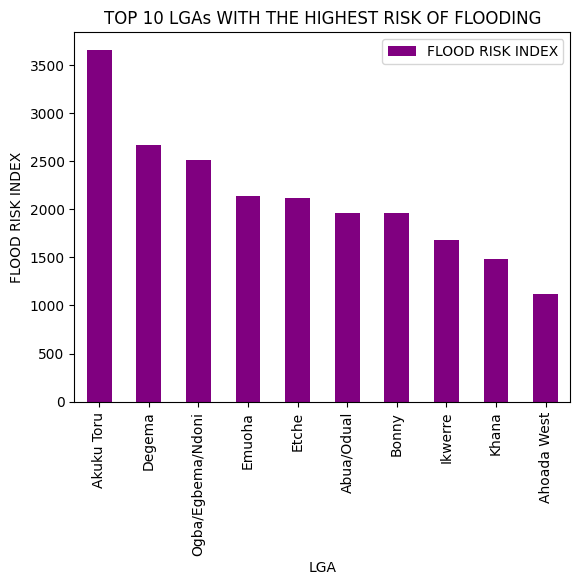

In [229]:
# Barchart showing the top LGAs with high flooding risk
top_LGA.plot(kind = 'bar', color = 'purple')
plt.ylabel('FLOOD RISK INDEX')
plt.xlabel('LGA')
plt.title('TOP 10 LGAs WITH THE HIGHEST RISK OF FLOODING')
# Save as PNG image
plt.savefig("Rivers_flood.png", dpi=300, bbox_inches="tight")
plt.show

In [230]:
# group LGA by mean rainfall
df7 = df.groupby('LGA')[['MEAN']].sum()
top_LGA = df7.nlargest(10, 'MEAN')
top_LGA

,MEAN
LGA,
Bonny,223.039906
Ogba/Egbema/Ndoni,209.495475
Ogu/Bolo,204.848002
Oyigbo,204.320469
Degema,202.519318
Okrika,202.047904
Eleme,201.918442
Port-Harcourt,199.276286
Omumma,197.945557


<function matplotlib.pyplot.show(close=None, block=None)>

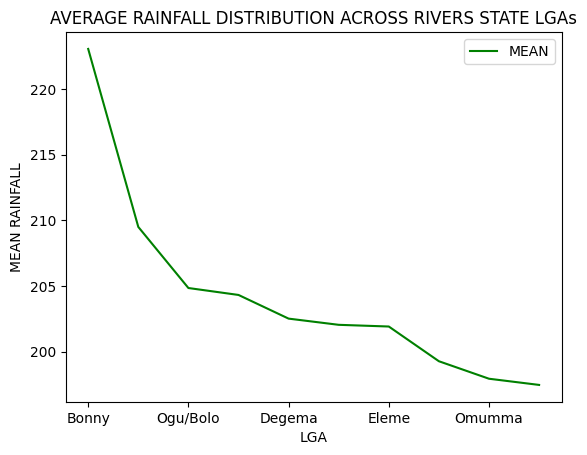

In [231]:
# Line chart showing the average rainfall distribution across River state
top_LGA.plot(kind = 'line', color = 'Green')
plt.ylabel('MEAN RAINFALL')
plt.xlabel('LGA')
plt.title('AVERAGE RAINFALL DISTRIBUTION ACROSS RIVERS STATE LGAs')
# Save as PNG image
plt.savefig("Rivers_rainfall_mean.png", dpi=300, bbox_inches="tight")
plt.show

In [232]:
# group LGA bymaximum rainfall
df8 = df.groupby('LGA')[['MAX']].max()
top_LGA = df8.nlargest(10, 'MAX')
top_LGA

,MAX
LGA,
Bonny,250.252518
Degema,235.843445
Ogba/Egbema/Ndoni,225.794296
Opobo/Nkoro,220.152710
Akuku Toru,216.551071
Emuoha,215.897964
Oyigbo,215.305298
Ogu/Bolo,215.176224
Okrika,212.901505


<function matplotlib.pyplot.show(close=None, block=None)>

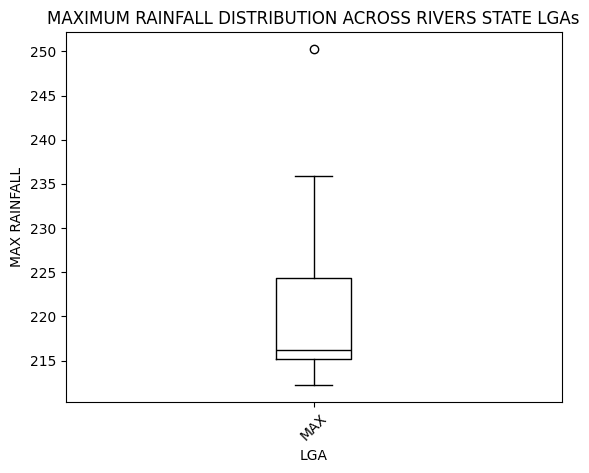

In [233]:
top_LGA.plot(kind = 'box', color = 'Black')
plt.ylabel('MAX RAINFALL')
plt.xlabel('LGA')
plt.xticks(rotation=45)
plt.title('MAXIMUM RAINFALL DISTRIBUTION ACROSS RIVERS STATE LGAs')
# Save as PNG image
plt.savefig("Rivers_rainfall_max.png", dpi=300, bbox_inches="tight")
plt.show

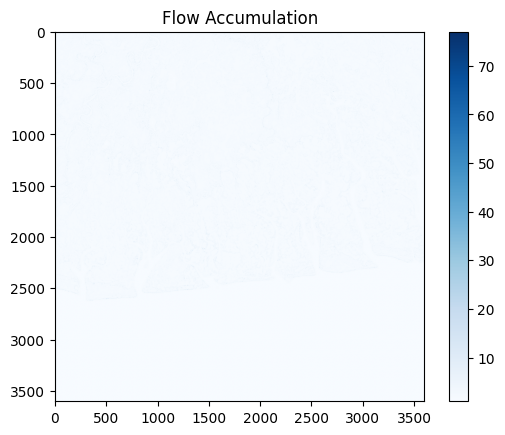

In [234]:
# Flow accumulation visualization
with rasterio.open("flow_accumulation.tif") as src:
    acc = src.read(1)

plt.imshow(acc, cmap="Blues")
plt.colorbar()
plt.title("Flow Accumulation")
plt.show()